
=== PERFORMANCE SUMMARY ===
final_capital   : 0.0000
total_pnl       : -100.0000
turnover_pct    : 143281.5847
sharpe          : 0.0000
max_drawdown    : -14.4701


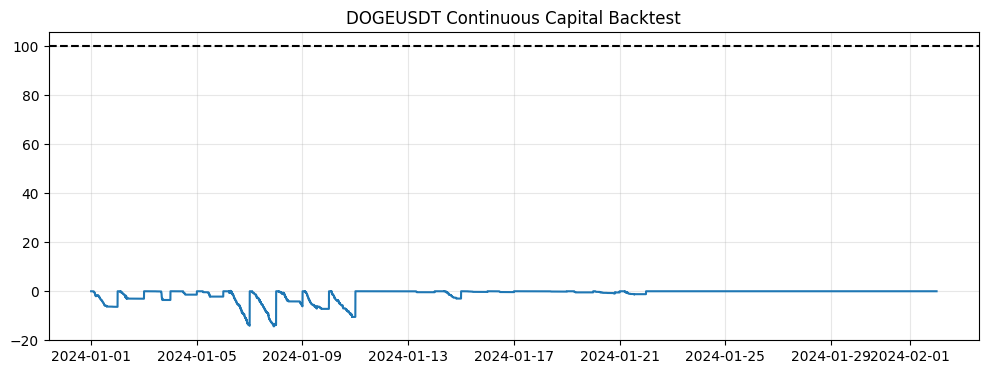

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import date, timedelta

from new_data_loader import DataLoader
from new_backtester import SimpleBacktester, BacktestConfig
from new_features_numba import rolling_z_numba
from new_performance import performance_summary


# =========================
# Config
# =========================
DATA_ROOT = "D:/fpa_data"
SYMBOL = "DOGEUSDT"
START_DATE = date(2024, 1, 1)
END_DATE = date(2024, 2, 1)
BOOK_FREQ = "1s"

Z_WINDOW = 60 * 120  # 60min @ 1s
Z_TH = 2.2

CONFIG = BacktestConfig(
    initial_capital=100.0,
    maker_fee_bp=5.0,
    taker_fee_bp=2.0,
    latency_ms=10,
    max_holding_seconds=240,
    target_bp=15.0,
    partial_bp=12.0,
    limit_ratio=0.7,
    stop_bp=8.0,
)


def daterange(start, end):
    d = start
    while d <= end:
        yield d
        d += timedelta(days=1)


loader = DataLoader(DATA_ROOT)

current_capital = CONFIG.initial_capital
total_turnover = 0.0

equity_ts = []
equity_vals = []
all_trades = []


for d in daterange(START_DATE, END_DATE):
    ymd = d.strftime("%Y-%m-%d")

    quotes = loader.load_bookticker_one_day(
        symbol=SYMBOL,
        ymd=ymd,
        freq=BOOK_FREQ,
    )
    if quotes.empty:
        continue

    bid = quotes["best_bid_qty"].to_numpy(dtype=np.float64)
    ask = quotes["best_ask_qty"].to_numpy(dtype=np.float64)

    denom = bid + ask
    imb = np.where(denom > 0, (bid - ask) / denom, np.nan)
    imb_z = rolling_z_numba(imb, Z_WINDOW)

    def signal(row, state):
        i = row["i"]
        z = imb_z[i]
        if np.isnan(z):
            return None
        if z >= Z_TH:
            return "LONG"
        if z <= -Z_TH:
            return "SHORT"
        return None

    bt = SimpleBacktester(quotes, config=CONFIG)

    trades, equity_exits, equity_full, turnover, end_capital = bt.run(
        signal,
        start_capital=current_capital,
    )

    current_capital = end_capital
    total_turnover += turnover

    if not trades.empty:
        all_trades.append(trades)

    if equity_full is not None and len(equity_full) > 0:
        equity_ts.extend(equity_full.index.to_numpy())
        equity_vals.extend(equity_full.to_numpy())


equity_all = pd.Series(
    np.asarray(equity_vals),
    index=pd.to_datetime(np.asarray(equity_ts)),
    name="equity",
).sort_index()

trades_all = pd.concat(all_trades, ignore_index=True) if all_trades else pd.DataFrame()

summary = performance_summary(
    equity_all,
    turnover=total_turnover,
    initial_capital=CONFIG.initial_capital,
)

print("\n=== PERFORMANCE SUMMARY ===")
for k, v in summary.items():
    print(f"{k:16s}: {v:.4f}")

# =========================
# Plot
# =========================
plt.figure(figsize=(12, 4))
plt.plot(equity_all.index, equity_all.values)
plt.axhline(CONFIG.initial_capital, color="black", linestyle="--")
plt.title(f"{SYMBOL} Continuous Capital Backtest")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from new_data_loader import DataLoader
from new_backtester import SimpleBacktester, BacktestConfig
from new_features_numba import rolling_z_numba
from new_performance import performance_metrics

# =========================
# CONFIG
# =========================
DATA_ROOT = "D:/fpa_data"
SYMBOL = "DOGEUSDT"
DAY = "2024-01-15"

BOOK_FREQ = None        # ❗ 다운샘플링 안 함 (raw)
DECISION_MS = 10        # 전략 판단 주기

Z_WINDOW_SEC = 60 * 60
Z_TH = 1.8

CONFIG = BacktestConfig(
    initial_capital=100.0,
    maker_fee_bp=5.0,
    taker_fee_bp=2.0,
    latency_ms=10,
    max_holding_seconds=240,
    limit_ratio=0.7,
    target_bp=15.0,
    partial_bp=12.0,
    stop_bp=8.0,
)

# =========================
# LOAD ONE DAY
# =========================
loader = DataLoader(DATA_ROOT)

quotes = loader.load_bookticker_one_day(
    symbol=SYMBOL,
    ymd=DAY,
    freq=BOOK_FREQ,   # raw
)

assert not quotes.empty

# =========================
# FEATURE (Numba, vectorized)
# =========================
bid = quotes["best_bid_qty"].values.astype(np.float64)
ask = quotes["best_ask_qty"].values.astype(np.float64)

den = bid + ask
imb = np.zeros_like(den)
mask = den > 0
imb[mask] = (bid[mask] - ask[mask]) / den[mask]

# rolling window in ticks (approx)
median_dt = quotes["ts"].diff().dt.total_seconds().median()
window_ticks = int(Z_WINDOW_SEC / median_dt)

imb_z = rolling_z_numba(imb, window_ticks)

# =========================
# DECISION MASK (10ms)
# =========================
ts_ns = quotes["ts"].values.astype("datetime64[ns]").astype("int64")
decision_mask = np.zeros(len(ts_ns), dtype=bool)
decision_mask[0] = True
decision_mask[1:] = (ts_ns[1:] - ts_ns[:-1]) >= DECISION_MS * 1_000_000

# =========================
# STRATEGY
# =========================
def signal(row, state):
    i = row["i"]

    # ❗ 10ms가 아니면 판단 안 함
    if not decision_mask[i]:
        return None

    if state["position"] is not None:
        return None

    z = imb_z[i]
    if np.isnan(z):
        return None

    if z >= Z_TH:
        return "LONG"
    if z <= -Z_TH:
        return "SHORT"
    return None

# =========================
# BACKTEST (ONE DAY)
# =========================
bt = SimpleBacktester(quotes, config=CONFIG)

trades, end_capital, turnover = bt.run(
    signal_func=signal,
    start_capital=CONFIG.initial_capital,
)

from new_performance import (
    equity_curve_from_exits,
    build_equity_full,
    performance_metrics,
)

equity_exit = equity_curve_from_exits(
    trades,
    initial_capital=CONFIG.initial_capital,
)

equity_full = build_equity_full(
    trades_df=trades,
    quote_ts=quotes["ts"],
    initial_capital=CONFIG.initial_capital,
)

metrics = performance_metrics(
    equity_full=equity_full,
    turnover=turnover,
    initial_capital=CONFIG.initial_capital,
)

print(metrics)

# =========================
# PERFORMANCE (단리)
# =========================
metrics = performance_metrics(
    equity_full=equity_full,
    turnover=turnover,
    initial_capital=CONFIG.initial_capital,
)

print("\n=== PERFORMANCE ===")
for k, v in metrics.items():
    print(f"{k:20s}: {v}")

print(f"\nEnd capital: {end_capital:.4f}")
print(f"Trades: {len(trades)}")

# =========================
# PLOT
# =========================
plt.figure(figsize=(12, 4))
plt.plot(equity_full.index, equity_full.values)
plt.axhline(0, color="black")
plt.title(f"Equity Curve (One Day, {DAY}, Simple PnL)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


ValueError: not enough values to unpack (expected 5, got 3)